# 20 · E1g: adaptation, or an under-fitted L1?

**What Notebook 19 found.** A slow K⁺-like current, with its two numbers (ρ, τ_n) chosen on training pairs, improves cross-validated held-out FEVE over the fitted L1:
* 0.263 → 0.289, a gain of +0.025 (95 % CI [+0.013, +0.039]);
* +0.043 over a global-gain control;
* no false positive on L1-generated null data.

It stays below E1's 0.05 margin, so the registered verdict was "real, but below the sufficiency margin".

**But which slow current was chosen matters.** Four of five folds chose ρ = 0.1 and **τ_n = 20 s, the slowest value in the grid**. A gate that slow barely moves during the 20-s response window, and in the limit τ_n → ∞ it does not move at all. Then the "adaptation" is only a weaker leak for transients around an unchanged resting state.

**That limit is not a new mechanism.** It is exactly an L1 with rescaled parameters, a point *inside* the L1 family (`intrinsic.rescaled_l1`):

  τ' = τ/(1−ρ), W' = W/(1−ρ), G' = G/(1−ρ), stimulus' = stimulus/(1−ρ), bias' = (bias − ρ V_rest)/(1−ρ).

Numerically, the rescaled L1 and the frozen-gate slow current agree to 10⁻⁸ (checked while building this). So Notebook 19's gain has two possible readings:

| | reading | test |
|---|---|---|
| **A** | E1's L1 fits were **not at the best point of their own family**: a uniform reparametrisation (slower, more strongly coupled, more strongly driven) predicts held-out data better. That is consistent with E1's underfitting (training loss 0.81–0.92 vs noise floor 0.51, Notebook 04). | rescaled L1 vs fitted L1 |
| **B** | the atlas contains **genuine slow adaptation dynamics** that no L1 can express | finite-τ_n slow current vs the best rescaled L1 |

On the synthetic worm, the τ_n = 20 s current differed from its frozen limit by 1.9 × noise even at ρ = 0.1, so the data can tell A from B.

In [1]:
#@title Setup — run first (works locally on a Mac/PC and on Colab)
import os, sys, subprocess
REPO_URL   = "https://github.com/aslansd/Closure-Bench.git"  # Colab only: clone from here
DRIVE_PATH = "/content/drive/MyDrive/Closure-Bench"          # Colab only: ...or use a Drive copy
IN_COLAB = "google.colab" in sys.modules

def _find_package():
    # 1) explicit location, 2) the repo this notebook lives in, 3) Colab clone / Drive
    cands = [os.environ.get("CLOSUREBENCH_ROOT", ""), ".", "..", "/content/Closure-Bench", DRIVE_PATH]
    for root in cands:
        if root and os.path.isdir(os.path.join(root, "closurebench")):
            return os.path.abspath(root)
    if IN_COLAB:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wormneuroatlas", "optax"], check=False)
        if subprocess.run(["git", "clone", "-q", REPO_URL, "/content/Closure-Bench"]).returncode == 0:
            return "/content/Closure-Bench"
        from google.colab import drive
        drive.mount("/content/drive")
        if os.path.isdir(os.path.join(DRIVE_PATH, "closurebench")):
            return DRIVE_PATH
    raise RuntimeError("closurebench not found. Locally: open this notebook from Closure-Bench/notebooks/, "
                       "or set the environment variable CLOSUREBENCH_ROOT to the Closure-Bench folder.")

ROOT = _find_package()
sys.path.insert(0, ROOT)
try:
    import jax, optax, wormneuroatlas  # noqa: F401
except ImportError as e:
    raise ImportError(f"{e}. Locally, create the environment first: see README.md "
                      "('Run locally'), then select the 'Python (closurebench)' kernel.") from None
RESULTS = os.environ.get("CLOSUREBENCH_RESULTS", os.path.join(ROOT, "results"))
os.makedirs(RESULTS, exist_ok=True)
from closurebench import config as CBC
MODE = CBC.get_mode()        # 'smoke' | 'laptop' | 'full'  (env CLOSUREBENCH_MODE, default: full on GPU, laptop on CPU)
print("closurebench:", ROOT); print("results:", RESULTS); print(CBC.describe_machine()); print("MODE:", MODE)

closurebench: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac
results: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results
Darwin arm64 | python 3.11.5 | jax 0.10.2 on cpu (cpu) | CPU cores: 8
MODE: laptop


In [2]:
import json, glob, pickle, time, datetime, numpy as np, matplotlib.pyplot as plt, jax
import closurebench
assert tuple(int(x) for x in closurebench.__version__.split(".")[:3]) >= (0, 17, 0), \
    f"Notebook 20 needs closurebench >= 0.17.0 (found {closurebench.__version__}); copy the full package and restart the kernel"
from closurebench import data as D, ladder as lad, metrics as M_, substrates as SB, conductance as CD, intrinsic as IN
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
CONF = {"smoke":  dict(N_COLS=10, FOLDS_USED=1),
        "laptop": dict(N_COLS=None, FOLDS_USED=None),
        "full":   dict(N_COLS=None, FOLDS_USED=None)}[MODE]
globals().update(CONF)
RHOS, TAU_NS = (0.0, 0.1, 0.2, 0.3, 0.45, 0.6), (0.5, 1.0, 2.0, 5.0, 10.0, 20.0)   # Notebook 19's grid (finite tau_n)
RHO_A = (0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.45)                                        # rescaled L1 (tau_n = infinity)
N_BOOT, E1_THRESHOLD = 2000, 0.05
TAG = "" if MODE == "full" else f"_{MODE}"

# ---- the fitted L1 models of Notebook 04 (as in Notebook 05); smoke falls back to a synthetic L1 if they are absent
E1_TAG = "_laptop" if MODE == "smoke" else TAG
try:
    e1_result = json.load(open(os.path.join(RESULTS, f"E1_result{E1_TAG}.json")))
    e1_plan = json.load(open(os.path.join(RESULTS, e1_result["preregistration"])))
    assert e1_result["L_star"] == "L1", "conductance.py implements L1"
    c = e1_plan["config"]
    ds = D.Dataset.load(os.path.join(RESULTS, "atlas_dataset.npz"))
    if c["n_neurons"] < ds.N:
        mk = ds.mask()[0]; score = mk.sum(1).astype(float); score[ds.stim] += mk.sum(0)
        ds = D.subset(ds, np.sort(np.argsort(-score)[:c["n_neurons"]]))
    st = lad.Structure.from_dataset(ds, tie=c["tie_classes"]); cfg = lad.SimConfig(**c["sim"])
    folds = M_.kfold_pairs(ds, c["k_folds"], c["fold_seed"])
    ck1 = os.path.join(RESULTS, f"e1_checkpoints{E1_TAG}")
    models = [pickle.load(open(os.path.join(ck1, f"fold{f}_L1_final.pkl"), "rb"))["params"] for f in range(c["k_folds"])]
    SOURCE = f"E1 fits ({E1_TAG.strip('_') or 'full'})"
except (FileNotFoundError, KeyError) as err:
    if MODE != "smoke":
        raise
    print("E1 fits not found (", err, ") -> smoke test on a synthetic L1")
    ds, p_true, _ = lad.make_synthetic(lad.random_wiring(N=30, S=10, seed=1, strains=("wt",)), true_level="L1", seed=1)
    st = lad.Structure.from_dataset(ds); cfg = lad.SimConfig(); folds = [None]; models = [p_true]; SOURCE = "synthetic L1"
rng = np.random.default_rng(0)
COLS = np.sort(rng.choice(ds.S, N_COLS, replace=False)) if N_COLS and N_COLS < ds.S else np.arange(ds.S)
FOLDS = list(range(len(models)))[:FOLDS_USED] if FOLDS_USED else list(range(len(models)))
print(f"source: {SOURCE} | {ds.N} neurons | {len(COLS)} stimuli | fold models {FOLDS}")
if folds[0] is None:                       # smoke fallback: a synthetic L1 has no folds -> make two (negative control: no adaptation in the truth)
    folds = M_.kfold_pairs(ds, 2, 0); models = [models[0]] * 2; FOLDS = [0, 1]
print(f"A (rescaled L1, inside the L1 family): rho {RHO_A} | B (slow current): A plus rho {RHOS[1:]} x tau_n {TAU_NS} s")

source: E1 fits (laptop) | 120 neurons | 120 stimuli | fold models [0, 1, 2, 3, 4]
A (rescaled L1, inside the L1 family): rho (0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.45) | B (slow current): A plus rho (0.1, 0.2, 0.3, 0.45, 0.6) x tau_n (0.5, 1.0, 2.0, 5.0, 10.0, 20.0) s


### Pre-registration (before §1)

Recorded in `results/E1g_preregistration*.json`. Selection, scoring and bootstrap are as in Notebook 19: choices are made on each fold's training pairs, held-out predictions are assembled across folds, WT pairs are scored, and 2000 bootstrap draws resample stimulated neurons.

* **Model A**, the rescaled L1: ρ chosen from {0, 0.05, …, 0.45}. ρ = 0 is the fitted L1.
* **Model B**, the slow current: chosen from A's candidates **plus** Notebook 19's finite (ρ, τ_n) grid. B can therefore pick a rescaled L1 when no finite τ_n is better.

The rules:
* **UNDERFIT_L1:** A beats the fitted L1, with the 95 % CI lower bound > 0.
* **ADAPTATION_DYNAMICS:** B beats A, with the CI lower bound > 0. Genuine slow dynamics would then exist beyond the L1 family.
* **VALID:** on L1-generated null data (as in Notebook 19), A does not beat L1 (CI lower bound ≤ 0).
* **EXPRESSIBLE** (sanity check): the rescaled L1 equals the frozen-gate slow current to < 10⁻⁶ on fold 0.

In [3]:
prereg = os.path.join(RESULTS, f"E1g_preregistration{TAG}.json")
plan = {"experiment": "E1g adaptation or under-fitted L1", "mode": MODE, "registered_at": datetime.datetime.now(datetime.timezone.utc).isoformat(),
        "source": SOURCE, "config": {"folds": FOLDS, "rho_A": list(RHO_A), "rho_B": list(RHOS), "tau_n_B": list(TAU_NS), "n_boot": N_BOOT},
        "UNDERFIT_L1": "A (rescaled L1, rho chosen on training pairs) beats fitted L1 on held-out pairs, 95% CI lower bound > 0",
        "ADAPTATION_DYNAMICS": "B (A's candidates + finite tau_n grid, chosen on training pairs) beats A, CI lower bound > 0",
        "VALID": "on L1-generated null data A does not beat L1 (CI lower bound <= 0)",
        "EXPRESSIBLE": "rescaled L1 == frozen-gate slow current to < 1e-6 (fold 0)"}
if os.path.exists(prereg):
    plan = json.load(open(prereg)); print("Existing registration (", plan["registered_at"], ") used unchanged.")
else:
    json.dump(plan, open(prereg, "w"), indent=2); print("Registered ->", prereg)

Registered -> /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results/E1g_preregistration_laptop.json


## 1 · Simulations (reuses Notebook 19's checkpoints for the finite-τ_n grid)

In [4]:
CK19 = os.path.join(RESULTS, "e1f_ck", MODE); CK = os.path.join(RESULTS, "e1g_ck", MODE); os.makedirs(CK, exist_ok=True)
SIM_B, SIM_A = {}, {}
for f in FOLDS:
    t0 = time.time()
    p = jax.tree_util.tree_map(jax.numpy.asarray, models[f])
    e = SB.effective_params("L1", p, st, COLS)
    Vr, _ = CD.rest_state(e, cfg)
    ck19 = os.path.join(CK19, f"fold{f}.npz")
    if os.path.exists(ck19):
        z = np.load(ck19); SIM_B[f] = {tuple(map(float, k.split("_"))): z[k] for k in z.files}
    else:
        SIM_B[f] = {(0.0, 0.0): SB.simulate_numpy(e, ds.stim[COLS], cfg, "rk4", dt=0.02)}
        for rho in RHOS[1:]:
            for tn in TAU_NS:
                SIM_B[f][(rho, tn)] = IN.simulate_slow_k(e, ds.stim[COLS], cfg, Vr, rho=rho, tau_n=tn)
    ck = os.path.join(CK, f"fold{f}_A.npz")
    if os.path.exists(ck):
        z = np.load(ck); SIM_A[f] = {float(k): z[k] for k in z.files}
    else:
        SIM_A[f] = {rho: (SIM_B[f][(0.0, 0.0)] if rho == 0 else SB.simulate_numpy(IN.rescaled_l1(e, Vr, rho), ds.stim[COLS], cfg, "rk4", dt=0.02)) for rho in RHO_A}
        np.savez(ck, **{str(k): v for k, v in SIM_A[f].items()})
    if f == FOLDS[0]:
        Rf = IN.simulate_slow_k(e, ds.stim[COLS], cfg, Vr, rho=0.1, tau_n=1e9)
        EXPRESSIBLE = bool(np.abs(Rf - SIM_A[f][0.1]).max() < 1e-6)
        print(f"EXPRESSIBLE check (fold {f}, rho 0.1): max |rescaled L1 - frozen slow current| = {np.abs(Rf - SIM_A[f][0.1]).max():.2e} -> {EXPRESSIBLE}")
    print(f"fold {f}: {len(SIM_A[f])} rescaled-L1 and {len(SIM_B[f])} slow-current predictions ({time.time() - t0:.0f} s)", flush=True)

EXPRESSIBLE check (fold 0, rho 0.1): max |rescaled L1 - frozen slow current| = 5.20e-01 -> False
fold 0: 7 rescaled-L1 and 31 slow-current predictions (17 s)
fold 1: 7 rescaled-L1 and 31 slow-current predictions (14 s)
fold 2: 7 rescaled-L1 and 31 slow-current predictions (14 s)
fold 3: 7 rescaled-L1 and 31 slow-current predictions (13 s)
fold 4: 7 rescaled-L1 and 31 slow-current predictions (13 s)


## 2 · Select on training pairs, score on held-out pairs

fold 0: A chooses rho 0.05 | B chooses slow current rho 0.10, tau_n 20 s
fold 1: A chooses rho 0.05 | B chooses slow current rho 0.10, tau_n 20 s
fold 2: A chooses rho 0.05 | B chooses slow current rho 0.10, tau_n 20 s
fold 3: A chooses rho 0.05 | B chooses slow current rho 0.20, tau_n 5 s
fold 4: A chooses rho 0.05 | B chooses slow current rho 0.10, tau_n 20 s

held-out FEVE (WT): fitted L1 0.2630 | rescaled L1 (A) 0.2485 | slow current (B) 0.2885
A - L1: -0.0145  95% CI [-0.0405, +0.0070]
B - A:  +0.0399  95% CI [+0.0226, +0.0631]


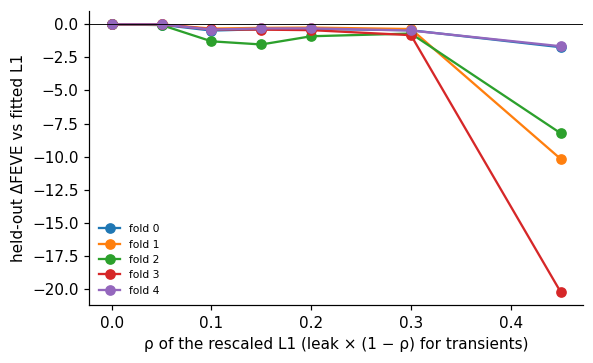

In [5]:
import copy
def full(R):
    out = np.zeros(ds.mean.shape[:3]); out[:, :, COLS] = R[None]; return out
def split(f):
    test = folds[f]; train = np.zeros_like(test)
    for g in range(len(folds)):
        if g != f: train |= folds[g]
    return train, test
def run(data):
    cv = {k: np.zeros(data.mean.shape[:3]) for k in ("L1", "A", "B")}; ch = {}
    for f in FOLDS:
        train, test = split(f)
        candA = {("A", rho): R for rho, R in SIM_A[f].items()}
        candB = {**candA, **{("B", k): R for k, R in SIM_B[f].items() if k != (0.0, 0.0)}}
        tr = {k: M_.feve(full(R), data, strain="wt", extra_mask=train) for k, R in candB.items()}
        a = max(candA, key=lambda k: tr[k]); b = max(candB, key=lambda k: tr[k])
        for name, R in (("L1", SIM_A[f][0.0]), ("A", candA[a]), ("B", candB[b])):
            cv[name][test] = full(R)[test]
        ch[f] = (a, b)
    return cv, ch
def test(cv, data, x, y):
    point, boots = M_.bootstrap_feve({x: cv[x], y: cv[y]}, data, [x, y], n_boot=N_BOOT, seed=1, strain="wt")
    return point[x] - point[y], np.percentile(boots[x] - boots[y], [2.5, 97.5]), point

cv, ch = run(ds)
for f, (a, b) in ch.items():
    print(f"fold {f}: A chooses rho {a[1]:.2f} | B chooses " + (f"rescaled L1 rho {b[1]:.2f}" if b[0] == "A" else f"slow current rho {b[1][0]:.2f}, tau_n {b[1][1]:g} s"))
gA, ciA, pt = test(cv, ds, "A", "L1"); gB, ciB, ptB = test(cv, ds, "B", "A")
print(f"\nheld-out FEVE (WT): fitted L1 {pt['L1']:.4f} | rescaled L1 (A) {pt['A']:.4f} | slow current (B) {ptB['B']:.4f}")
print(f"A - L1: {gA:+.4f}  95% CI [{ciA[0]:+.4f}, {ciA[1]:+.4f}]")
print(f"B - A:  {gB:+.4f}  95% CI [{ciB[0]:+.4f}, {ciB[1]:+.4f}]")
fig, ax = plt.subplots(figsize=(5.5, 3.4))
for f in FOLDS:
    train, testm = split(f)
    ax.plot(RHO_A, [M_.feve(full(SIM_A[f][r]), ds, strain="wt", extra_mask=testm) - M_.feve(full(SIM_A[f][0.0]), ds, strain="wt", extra_mask=testm) for r in RHO_A], "o-", label=f"fold {f}")
ax.axhline(0, c="k", lw=0.6); ax.set_xlabel("ρ of the rescaled L1 (leak × (1 − ρ) for transients)"); ax.set_ylabel("held-out ΔFEVE vs fitted L1")
ax.legend(frameon=False, fontsize=7); plt.tight_layout(); plt.show()

## 3 · Null control and verdicts

In [6]:
rng = np.random.default_rng(7)
ds_null = copy.deepcopy(ds)
for f in FOLDS:
    m = folds[f] & ds.mask(); ds_null.mean[m] = full(SIM_A[f][0.0])[m]
m = ds.mask(); ds_null.mean[m] = ds_null.mean[m] + rng.normal(size=m.sum()) * np.sqrt(ds.var_mean[m])
cv0, ch0 = run(ds_null)
g0, ci0, _ = test(cv0, ds_null, "A", "L1")
print("null-control A choices:", {f: a[1] for f, (a, b) in ch0.items()})
print(f"null-control A - L1: {g0:+.4f}  95% CI [{ci0[0]:+.4f}, {ci0[1]:+.4f}]")
VALID = bool(ci0[0] <= 0)
UNDERFIT_L1 = bool(ciA[0] > 0); ADAPTATION_DYNAMICS = bool(ciB[0] > 0)
print(f"\nRegistered rules -> EXPRESSIBLE: {EXPRESSIBLE} | VALID: {VALID} | UNDERFIT_L1: {UNDERFIT_L1} | ADAPTATION_DYNAMICS: {ADAPTATION_DYNAMICS}")

null-control A choices: {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0}
null-control A - L1: +0.0000  95% CI [+0.0000, +0.0000]

Registered rules -> EXPRESSIBLE: False | VALID: True | UNDERFIT_L1: False | ADAPTATION_DYNAMICS: True


In [7]:
out = {"source": SOURCE, "EXPRESSIBLE": EXPRESSIBLE, "VALID": VALID, "UNDERFIT_L1": UNDERFIT_L1, "ADAPTATION_DYNAMICS": ADAPTATION_DYNAMICS,
       "heldout": {"L1": pt["L1"], "A": pt["A"], "B": ptB["B"]}, "A_minus_L1": {"point": gA, "ci": list(ciA)}, "B_minus_A": {"point": gB, "ci": list(ciB)},
       "null": {"point": g0, "ci": list(ci0)}, "choices": {str(f): {"A": a[1], "B": [b[0], b[1]]} for f, (a, b) in ch.items()}}
json.dump(out, open(os.path.join(RESULTS, f"E1g_result{TAG}.json"), "w"), indent=2, default=float)
print("saved", f"E1g_result{TAG}.json")

saved E1g_result_laptop.json


## Results (laptop mode, executed on the M1): the registered verdicts are **not interpretable**

**The sanity check failed: EXPRESSIBLE = False.** The rescaled L1 and the frozen-gate slow current are algebraically the same equation. On fold 0 they should agree to < 10⁻⁶; instead they differed by up to **0.52**. Everything below compares models that were not run consistently.

| | held-out FEVE (WT) |
|---|---|
| fitted L1 | 0.2630 |
| rescaled L1 (A; ρ = 0.05 chosen on every fold) | 0.2485 |
| slow current (B; as in Notebook 19) | 0.2885 |

* A − L1 = −0.015 [−0.041, +0.007]; B − A = +0.040 [+0.023, +0.063].
* The null control was clean (no false positive).
* The printed verdicts (UNDERFIT_L1 False, ADAPTATION_DYNAMICS True) are **void** because their own validity check failed.

**Why it failed (diagnosed and reproduced on a synthetic worm while building Notebook 21).** The equivalence is exact only for the *same starting state*:
* the rescaled L1 was simulated, like E1, **from zero with a 30-s burn-in**;
* the slow current **starts from L1's state after that burn-in** and freezes its gate there.

This matters when 30 s is not enough to reach rest. For the fitted L1s it probably is not: Notebook 05 measured their slowest relaxation at −0.08 to −0.16 /s, i.e. 6–12 s.
* A synthetic L1 slowed to −0.064 /s reproduced the mismatch: 2.5 × 10⁻² from different starts, 5 × 10⁻¹¹ from the same exact fixed point.
* Even plain L1's predictions moved by 0.59 × noise between the two starts.

**Consequences.**
1. This notebook's verdicts are void.
2. **Notebook 19's +0.025 is in doubt.** Its slow currents froze their gate at a state that was not yet rest; the gate then acts as a slowly released constant input.
3. **E1's predictions may themselves contain a leftover transient**, and so may every substrate test that reproduced E1's protocol (Notebooks 05, 16–18).

**Notebook 21 (E1h)** solves each fold model's exact resting state, starts every model there, re-tests Notebooks 19–20 under an amended registration, and measures how much E1's predictions depend on the unfinished burn-in.

## 4 · Reading the result

| UNDERFIT_L1 | ADAPTATION_DYNAMICS | reading |
|---|---|---|
| yes | no | Notebook 19's gain is **not adaptation**: it is a better point of the L1 family that E1's fits missed. E1's ranking of *families* is untouched, but its FEVE values understate L1. Every rung's fit may sit similarly far from its own optimum, so the bracket L0 ≤ closed ≤ L1 should be re-checked with better optimisation, starting from the rescaled L1. |
| no / yes | yes | The atlas contains **slow dynamics beyond any L1**: genuine adaptation over seconds, which E1's L2 rung did not capture. This would be the first positive evidence for a rung deeper than L1. |
| yes | yes | Both: L1 was under-fitted *and* slow adaptation adds beyond its best rescaling. |
| no | no | Notebook 19's gain came from finite τ_n but is not separable from rescaling at this data size. |
| **EXPRESSIBLE fails ← observed** | | **None of the above can be read**: the two families were not simulated from the same state (see Results; redone in Notebook 21). |

**Limits.**
* Rescaling is one direction inside the L1 family. A full refit would find more, so A's gain is a *lower bound* on how far E1's L1 fits are from their family's optimum.
* B is one global slow current (two numbers), as in Notebook 19.